# Import

In [1]:
# --- General ---
import time
import numpy as np
import pyvisa as pvisa
import matplotlib.pyplot as plt
import pandas as pd

# --- Power control ---
#import nidaqmx # ND filter motor
#from instrcomms import Communications
from pylablib.devices.Thorlabs import MFF # Flip mount
from pylablib.devices.Thorlabs import PM160 # Power meter

# --- For Andor ---
import pylablib as pll
pll.par["devices/dlls/andor_shamrock"] = "C:/Program Files/Andor SDK/Shamrock64"
pll.par["devices/dlls/andor_sdk2"] = "C:/Program Files/Andor SDK"
from pylablib.devices import Andor

# --- Rotation mount ---
from thorlabs_elliptec import ELLx, ELLError, ELLStatus, list_devices
import thorlabs_elliptec


In [2]:
rm = pvisa.ResourceManager()
resources = rm.list_resources()
print("List")
for res in resources:
    print(res)

List
GPIB0::13::INSTR
GPIB0::2::INSTR
GPIB1::3::INSTR
GPIB1::8::INSTR
PXI0::4-0.0::INSTR
USB0::0x05E6::0x2636::4353546::0::INSTR
USB0::0x05E6::0x2636::4437673::0::INSTR
USB0::0x0957::0x3D18::MY59030016::0::INSTR
USB0::0x1313::0x8078::P0005244::0::INSTR
USB0::0x1313::0x8078::PM001388::0::INSTR
USB0::0x2EC7::0x6522::802557043747210033::0::INSTR
ASRL3::INSTR
ASRL5::INSTR


# Initialize

In [6]:
#Andor.list_shamrock_spectrographs()

['KY-3764']

In [31]:
# --- Andor ---
cam = Andor.AndorSDK2Camera(temperature=-75, fan_mode="full") # Cooling setpoint
spec = Andor.ShamrockSpectrograph()
cam.set_cooler()
cam.set_temperature(-75,enable_cooler=True)
print("Cooler: ", cam.is_cooler_on())
cam.setup_shutter("auto")
cam.set_read_mode("fvb")

Cooler:  True


'fvb'

In [11]:
# --- Connect power meter ---
#pm = PM160("COM2")
pm = PM160('USB0::0x1313::0x8078::P0005244::0::INSTR') #TBD
pm.open()
pm.enable_autorange

<bound method GenericPM.enable_autorange of <pylablib.devices.Thorlabs.misc.PM160 object at 0x0000012857066760>>

In [12]:
# --- Flip mount ---
#Import pyft232
serial = "37000705"
flip_mount = MFF(serial)
flip_mount.open()  # explicitly open the FTDI backend
flip_mount.move_to_state(0) #Block

C:\Users\HP\.conda\envs\LL_Group_qcodes\lib\site-packages\pylablib\devices\Thorlabs\kinesis.py:230: UserWarning: model number MFF002 doesn't match the device ID prefix 37(MFF10.)
  warnings.warn("model number {} doesn't match the device ID prefix {}({})".format(model_no,port,port_model_no))


In [13]:
# --- Check rotation mount ---
print(list_devices())
print(thorlabs_elliptec.find_device())

device=COM3, manufacturer=Intel, product=None, vid=None, pid=None, serial_number=None, location=None
device=COM5, manufacturer=FTDI, product=None, vid=0x0403, pid=0x6001, serial_number=AC00HSRYA, location=None
COM3 - Intel(R) Active Management Technology - SOL (COM3)


In [18]:
# --- Connect rotation mounts ---
# Define the ID in ELLO GUI first
stage1 = ELLx(x=14, serial_port="COM4", device_id=1)

In [19]:
stage2 = ELLx(x=14, serial_port=stage1, device_id=2)

In [38]:
# --- Check status ---
print("CCD temperature: ", cam.get_temperature(), ", status: ", cam.get_temperature_status())

print("Rotation mounts:")
print(f"{stage1.model_number} #{stage1.device_id} on {stage1.port_name}, serial number {stage1.serial_number}, status {stage1.status.description}")
print(f"{stage2.model_number} #{stage2.device_id} on {stage2.port_name}, serial number {stage2.serial_number}, status {stage2.status.description}")

print("Power meter status: ", pm.get_full_status(include="all"))

CCD temperature:  -75.43000030517578 , status:  not_stabilized
Rotation mounts:
ELL14/M #1 on COM4, serial number 11401337, status ok
ELL14/M #2 on COM4, serial number 11401440, status ok
Power meter status:  {'mode': 'power', 'autorange': True, 'wavelength': 6.33e-07, 'range': 8.996119e-06, 'reading': 1.54825287e-07}


In [39]:
# Move device to the home position
stage1.home()
stage2.home()

In [41]:
stage1.move_absolute(180, blocking=True) #check stage 1 or 2
stage1.home()

In [42]:
# Rotation mount steps
initial_angle1 = 0
initial_angle2 = 0
stage1_steps = np.linspace(initial_angle1, initial_angle1 + 360, 25)
stage1_steps[-1] = stage1_steps[0]
print("Mount 1 steps: ", stage1_steps)
stage2_steps = np.arange(initial_angle2, initial_angle2 + 181, 9)
print("Mount 2 steps: ", stage2_steps)

# Laser wavelength in nm
laser_wavelength = 532

Mount 1 steps:  [  0.  15.  30.  45.  60.  75.  90. 105. 120. 135. 150. 165. 180. 195.
 210. 225. 240. 255. 270. 285. 300. 315. 330. 345.   0.]
Mount 2 steps:  [  0   9  18  27  36  45  54  63  72  81  90  99 108 117 126 135 144 153
 162 171 180]


In [49]:
# Rotation mount steps
initial_angle1 = 0
initial_angle2 = 0
stage1_steps = np.linspace(initial_angle1, initial_angle1 + 360, 25)
stage1_steps[-1] = stage1_steps[0]
print("Mount 1 steps: ", stage1_steps)
stage2_steps = [48, 47, 46, 45, 44, 43, 42]
print("Mount 2 steps: ", stage2_steps)

# Laser wavelength in nm
laser_wavelength = 633

Mount 1 steps:  [  0.  15.  30.  45.  60.  75.  90. 105. 120. 135. 150. 165. 180. 195.
 210. 225. 240. 255. 270. 285. 300. 315. 330. 345.   0.]
Mount 2 steps:  [48, 47, 46, 45, 44, 43, 42]


# Excitation polarization test


Setting Stage 2 to 48.0°
  Stage 1: 0.0°, Stage 2: 48.0° → Power: 1.4763e-03 W
  Stage 1: 15.0°, Stage 2: 48.0° → Power: 1.4600e-03 W
  Stage 1: 30.0°, Stage 2: 48.0° → Power: 1.4534e-03 W
  Stage 1: 45.0°, Stage 2: 48.0° → Power: 1.5039e-03 W
  Stage 1: 60.0°, Stage 2: 48.0° → Power: 1.5875e-03 W
  Stage 1: 75.0°, Stage 2: 48.0° → Power: 1.6867e-03 W
  Stage 1: 90.0°, Stage 2: 48.0° → Power: 1.7761e-03 W
  Stage 1: 105.0°, Stage 2: 48.0° → Power: 1.7975e-03 W
  Stage 1: 120.0°, Stage 2: 48.0° → Power: 1.8441e-03 W
  Stage 1: 135.0°, Stage 2: 48.0° → Power: 1.7616e-03 W
  Stage 1: 150.0°, Stage 2: 48.0° → Power: 1.6902e-03 W
  Stage 1: 165.0°, Stage 2: 48.0° → Power: 1.5624e-03 W
  Stage 1: 180.0°, Stage 2: 48.0° → Power: 1.5051e-03 W
  Stage 1: 195.0°, Stage 2: 48.0° → Power: 1.4783e-03 W
  Stage 1: 210.0°, Stage 2: 48.0° → Power: 1.4496e-03 W
  Stage 1: 225.0°, Stage 2: 48.0° → Power: 1.5043e-03 W
  Stage 1: 240.0°, Stage 2: 48.0° → Power: 1.5857e-03 W
  Stage 1: 255.0°, Stage 2: 48

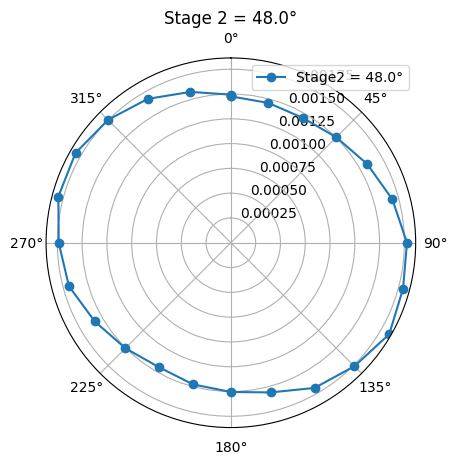


Setting Stage 2 to 47.0°
  Stage 1: 0.0°, Stage 2: 47.0° → Power: 1.5096e-03 W
  Stage 1: 15.0°, Stage 2: 47.0° → Power: 1.4834e-03 W
  Stage 1: 30.0°, Stage 2: 47.0° → Power: 1.4918e-03 W
  Stage 1: 45.0°, Stage 2: 47.0° → Power: 1.5486e-03 W
  Stage 1: 60.0°, Stage 2: 47.0° → Power: 1.6365e-03 W
  Stage 1: 75.0°, Stage 2: 47.0° → Power: 1.6934e-03 W
  Stage 1: 90.0°, Stage 2: 47.0° → Power: 1.7675e-03 W
  Stage 1: 105.0°, Stage 2: 47.0° → Power: 1.8130e-03 W
  Stage 1: 120.0°, Stage 2: 47.0° → Power: 1.8014e-03 W
  Stage 1: 135.0°, Stage 2: 47.0° → Power: 1.7116e-03 W
  Stage 1: 150.0°, Stage 2: 47.0° → Power: 1.6526e-03 W
  Stage 1: 165.0°, Stage 2: 47.0° → Power: 1.5465e-03 W
  Stage 1: 180.0°, Stage 2: 47.0° → Power: 1.5296e-03 W
  Stage 1: 195.0°, Stage 2: 47.0° → Power: 1.4755e-03 W
  Stage 1: 210.0°, Stage 2: 47.0° → Power: 1.5014e-03 W
  Stage 1: 225.0°, Stage 2: 47.0° → Power: 1.5641e-03 W
  Stage 1: 240.0°, Stage 2: 47.0° → Power: 1.6047e-03 W
  Stage 1: 255.0°, Stage 2: 47

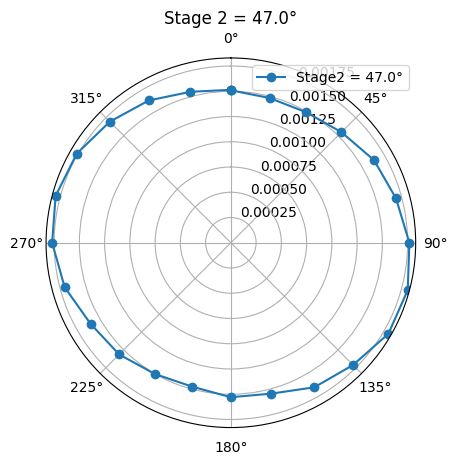


Setting Stage 2 to 46.0°
  Stage 1: 0.0°, Stage 2: 46.0° → Power: 1.4900e-03 W
  Stage 1: 15.0°, Stage 2: 46.0° → Power: 1.5400e-03 W
  Stage 1: 30.0°, Stage 2: 46.0° → Power: 1.5298e-03 W
  Stage 1: 45.0°, Stage 2: 46.0° → Power: 1.6067e-03 W
  Stage 1: 60.0°, Stage 2: 46.0° → Power: 1.6734e-03 W
  Stage 1: 75.0°, Stage 2: 46.0° → Power: 1.7049e-03 W
  Stage 1: 90.0°, Stage 2: 46.0° → Power: 1.7606e-03 W
  Stage 1: 105.0°, Stage 2: 46.0° → Power: 1.7453e-03 W
  Stage 1: 120.0°, Stage 2: 46.0° → Power: 1.7385e-03 W
  Stage 1: 135.0°, Stage 2: 46.0° → Power: 1.6602e-03 W
  Stage 1: 150.0°, Stage 2: 46.0° → Power: 1.5961e-03 W
  Stage 1: 165.0°, Stage 2: 46.0° → Power: 1.5410e-03 W
  Stage 1: 180.0°, Stage 2: 46.0° → Power: 1.5190e-03 W
  Stage 1: 195.0°, Stage 2: 46.0° → Power: 1.5330e-03 W
  Stage 1: 210.0°, Stage 2: 46.0° → Power: 1.5753e-03 W
  Stage 1: 225.0°, Stage 2: 46.0° → Power: 1.6281e-03 W
  Stage 1: 240.0°, Stage 2: 46.0° → Power: 1.6604e-03 W
  Stage 1: 255.0°, Stage 2: 46

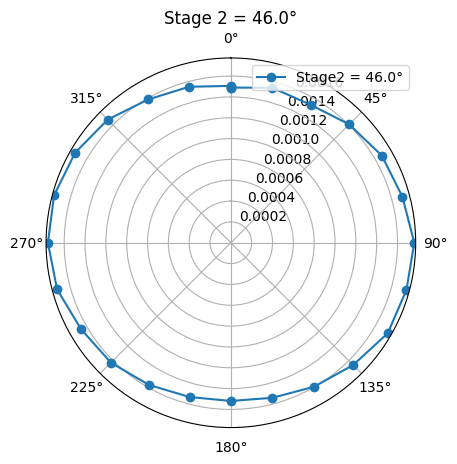


Setting Stage 2 to 45.0°
  Stage 1: 0.0°, Stage 2: 45.0° → Power: 1.4890e-03 W
  Stage 1: 15.0°, Stage 2: 45.0° → Power: 1.5220e-03 W
  Stage 1: 30.0°, Stage 2: 45.0° → Power: 1.5908e-03 W
  Stage 1: 45.0°, Stage 2: 45.0° → Power: 1.6618e-03 W
  Stage 1: 60.0°, Stage 2: 45.0° → Power: 1.6977e-03 W
  Stage 1: 75.0°, Stage 2: 45.0° → Power: 1.7704e-03 W
  Stage 1: 90.0°, Stage 2: 45.0° → Power: 1.7532e-03 W
  Stage 1: 105.0°, Stage 2: 45.0° → Power: 1.7524e-03 W
  Stage 1: 120.0°, Stage 2: 45.0° → Power: 1.6671e-03 W
  Stage 1: 135.0°, Stage 2: 45.0° → Power: 1.6159e-03 W
  Stage 1: 150.0°, Stage 2: 45.0° → Power: 1.5649e-03 W
  Stage 1: 165.0°, Stage 2: 45.0° → Power: 1.5157e-03 W
  Stage 1: 180.0°, Stage 2: 45.0° → Power: 1.4900e-03 W
  Stage 1: 195.0°, Stage 2: 45.0° → Power: 1.5275e-03 W
  Stage 1: 210.0°, Stage 2: 45.0° → Power: 1.5702e-03 W
  Stage 1: 225.0°, Stage 2: 45.0° → Power: 1.6724e-03 W
  Stage 1: 240.0°, Stage 2: 45.0° → Power: 1.7034e-03 W
  Stage 1: 255.0°, Stage 2: 45

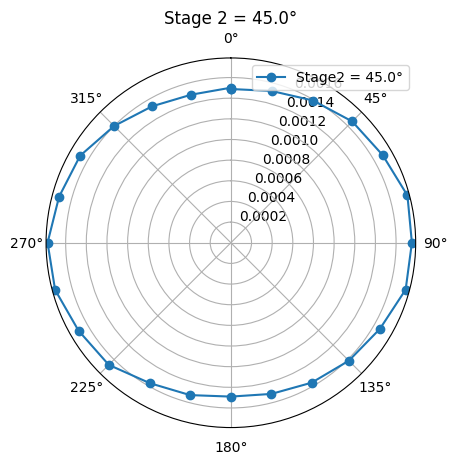


Setting Stage 2 to 44.0°
  Stage 1: 0.0°, Stage 2: 44.0° → Power: 1.5088e-03 W
  Stage 1: 15.0°, Stage 2: 44.0° → Power: 1.5379e-03 W
  Stage 1: 30.0°, Stage 2: 44.0° → Power: 1.6322e-03 W
  Stage 1: 45.0°, Stage 2: 44.0° → Power: 1.7122e-03 W
  Stage 1: 60.0°, Stage 2: 44.0° → Power: 1.7692e-03 W
  Stage 1: 75.0°, Stage 2: 44.0° → Power: 1.7588e-03 W
  Stage 1: 90.0°, Stage 2: 44.0° → Power: 1.7512e-03 W
  Stage 1: 105.0°, Stage 2: 44.0° → Power: 1.7267e-03 W
  Stage 1: 120.0°, Stage 2: 44.0° → Power: 1.6359e-03 W
  Stage 1: 135.0°, Stage 2: 44.0° → Power: 1.5673e-03 W
  Stage 1: 150.0°, Stage 2: 44.0° → Power: 1.4967e-03 W
  Stage 1: 165.0°, Stage 2: 44.0° → Power: 1.4792e-03 W
  Stage 1: 180.0°, Stage 2: 44.0° → Power: 1.5092e-03 W
  Stage 1: 195.0°, Stage 2: 44.0° → Power: 1.5594e-03 W
  Stage 1: 210.0°, Stage 2: 44.0° → Power: 1.6561e-03 W
  Stage 1: 225.0°, Stage 2: 44.0° → Power: 1.7006e-03 W
  Stage 1: 240.0°, Stage 2: 44.0° → Power: 1.7551e-03 W
  Stage 1: 255.0°, Stage 2: 44

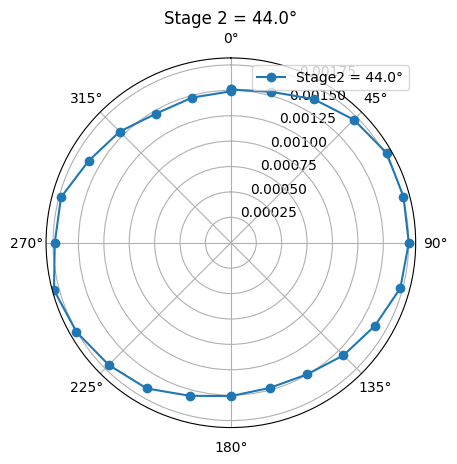


Setting Stage 2 to 43.0°
  Stage 1: 0.0°, Stage 2: 43.0° → Power: 1.4914e-03 W
  Stage 1: 15.0°, Stage 2: 43.0° → Power: 1.5767e-03 W
  Stage 1: 30.0°, Stage 2: 43.0° → Power: 1.6459e-03 W
  Stage 1: 45.0°, Stage 2: 43.0° → Power: 1.7588e-03 W
  Stage 1: 60.0°, Stage 2: 43.0° → Power: 1.8179e-03 W
  Stage 1: 75.0°, Stage 2: 43.0° → Power: 1.8251e-03 W
  Stage 1: 90.0°, Stage 2: 43.0° → Power: 1.7906e-03 W
  Stage 1: 105.0°, Stage 2: 43.0° → Power: 1.7006e-03 W
  Stage 1: 120.0°, Stage 2: 43.0° → Power: 1.5930e-03 W
  Stage 1: 135.0°, Stage 2: 43.0° → Power: 1.5188e-03 W
  Stage 1: 150.0°, Stage 2: 43.0° → Power: 1.4526e-03 W
  Stage 1: 165.0°, Stage 2: 43.0° → Power: 1.4406e-03 W
  Stage 1: 180.0°, Stage 2: 43.0° → Power: 1.4849e-03 W
  Stage 1: 195.0°, Stage 2: 43.0° → Power: 1.5704e-03 W
  Stage 1: 210.0°, Stage 2: 43.0° → Power: 1.6720e-03 W
  Stage 1: 225.0°, Stage 2: 43.0° → Power: 1.7710e-03 W
  Stage 1: 240.0°, Stage 2: 43.0° → Power: 1.8208e-03 W
  Stage 1: 255.0°, Stage 2: 43

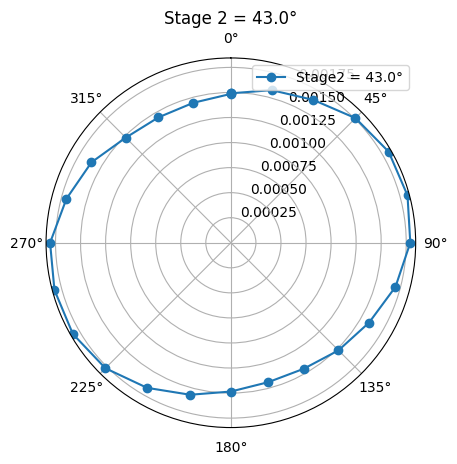


Setting Stage 2 to 42.0°
  Stage 1: 0.0°, Stage 2: 42.0° → Power: 1.4494e-03 W
  Stage 1: 15.0°, Stage 2: 42.0° → Power: 1.5896e-03 W
  Stage 1: 30.0°, Stage 2: 42.0° → Power: 1.6863e-03 W
  Stage 1: 45.0°, Stage 2: 42.0° → Power: 1.8102e-03 W
  Stage 1: 60.0°, Stage 2: 42.0° → Power: 1.8736e-03 W
  Stage 1: 75.0°, Stage 2: 42.0° → Power: 1.8559e-03 W
  Stage 1: 90.0°, Stage 2: 42.0° → Power: 1.8022e-03 W
  Stage 1: 105.0°, Stage 2: 42.0° → Power: 1.6820e-03 W
  Stage 1: 120.0°, Stage 2: 42.0° → Power: 1.5571e-03 W
  Stage 1: 135.0°, Stage 2: 42.0° → Power: 1.4396e-03 W
  Stage 1: 150.0°, Stage 2: 42.0° → Power: 1.4059e-03 W
  Stage 1: 165.0°, Stage 2: 42.0° → Power: 1.3900e-03 W
  Stage 1: 180.0°, Stage 2: 42.0° → Power: 1.4692e-03 W
  Stage 1: 195.0°, Stage 2: 42.0° → Power: 1.5696e-03 W
  Stage 1: 210.0°, Stage 2: 42.0° → Power: 1.7177e-03 W
  Stage 1: 225.0°, Stage 2: 42.0° → Power: 1.8228e-03 W
  Stage 1: 240.0°, Stage 2: 42.0° → Power: 1.8657e-03 W
  Stage 1: 255.0°, Stage 2: 42

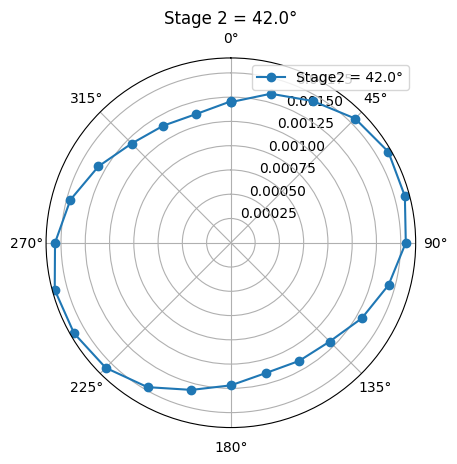


Measurement finished. Data saved to 'power_map_20251111_135937.csv'


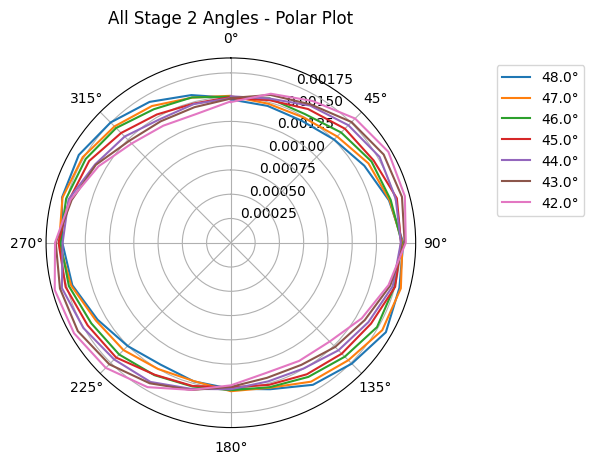

In [51]:
# --- Configuration ---
pm.set_wavelength(laser_wavelength * 1e-9)
flip_mount.move_to_state(1)  # Remove

# --- Data storage ---
power_matrix = np.zeros((len(stage1_steps), len(stage2_steps)))

# --- Prepare polar plot window ---
plt.ion()  # Interactive mode on

# --- Measurement loop ---
for col, angle2 in enumerate(stage2_steps):
    print(f"\nSetting Stage 2 to {angle2:.1f}°")
    stage2.move_absolute(angle2, blocking=True)
    time.sleep(0.2)

    for row, angle1 in enumerate(stage1_steps):
        stage1.move_absolute(angle1, blocking=True)
        time.sleep(0.2)
        power = pm.get_power()
        power_matrix[row, col] = power
        print(f"  Stage 1: {angle1:.1f}°, Stage 2: {angle2:.1f}° → Power: {power:.4e} W")

    # --- Create a new polar plot for this stage2 position ---
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_title(f"Stage 2 = {angle2:.1f}°")
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("N")

    theta = np.deg2rad(stage1_steps)
    r = power_matrix[:, col]
    theta = np.append(theta, theta[0])
    r = np.append(r, r[0])

    ax.plot(theta, r, 'o-', label=f"Stage2 = {angle2:.1f}°")
    ax.legend(loc='upper right')

    plt.show(block=False)   # show immediately but don’t block code
    plt.pause(0.5)          # short pause so the figure can render

plt.ioff()

# --- Convert to DataFrame ---
df = pd.DataFrame(power_matrix,
                  index=[f"{a1:.1f}" for a1 in stage1_steps],
                  columns=[f"{a2:.1f}" for a2 in stage2_steps])

# --- Save to CSV ---
timestamp = time.strftime("%Y%m%d_%H%M%S")
filename = f"power_map_{timestamp}.csv"
df.to_csv(filename)
print(f"\nMeasurement finished. Data saved to '{filename}'")

# --- Final combined polar plots for all Stage2 values ---
fig2, ax2 = plt.subplots(subplot_kw={'projection': 'polar'})
ax2.set_title("All Stage 2 Angles - Polar Plot")
ax2.set_theta_direction(-1)
ax2.set_theta_zero_location("N")

for col, angle2 in enumerate(stage2_steps):
    theta = np.deg2rad(stage1_steps)
    r = power_matrix[:, col]
    theta = np.append(theta, theta[0])
    r = np.append(r, r[0])
    ax2.plot(theta, r, label=f"{angle2:.1f}°")

ax2.legend(bbox_to_anchor=(1.2, 1.0))
plt.show()


# Spectrum parameters

In [54]:
# Set Grating
spec.set_grating(1) # 1 for 150, 2 for 1200
spec.set_grating_offset(-32) # -25 for 150, -32 for 1200?

# Exposure time in sec
exposure_time = 0.5 
cam.set_exposure(exposure_time)

# Spectrum center and unit (nm, eV, cm-1)
center_value = 1370
unit = "cm-1"

def center_setting(center = center_value, Unit=unit, ex_wavelength=laser_wavelength):
    """Set spectrograph center wavelength."""
    if Unit == "nm":
        center_wavelength = center
    elif Unit == "eV":
        center_wavelength = 1240 / center
    elif Unit == "cm-1":
        center_wavelength = 1 / ((1 / ex_wavelength) - center / 1e7)
    else:
        raise ValueError("unit must be 'nm', 'eV', or 'cm-1'")
    
    spec.set_wavelength(center_wavelength * 1e-9)  # convert to meters

center_setting()

# Create value for x-axis
spec.setup_pixels_from_camera(cam) # setup camera sensor parameters (number and size of pixels) for wavelength calibration

# Unit convertion
wavelengths = spec.get_calibration()*(10**9) # Get x-axis value in nm
photo_energy = 1240/wavelengths # Get x-axis value in eV
raman_shift = (10**7)*(1/laser_wavelength-1/wavelengths) # Get x-axis value in cm-1

# Single spectrum

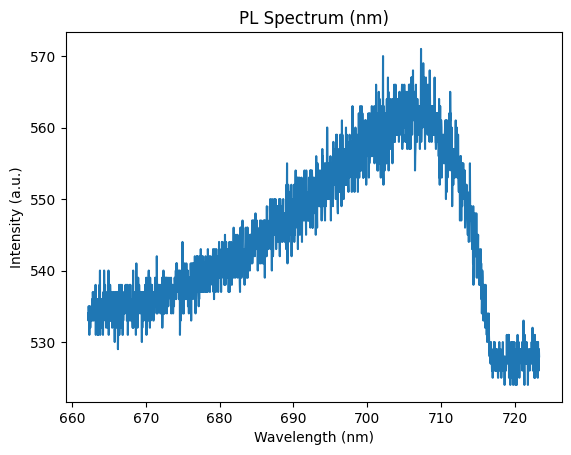

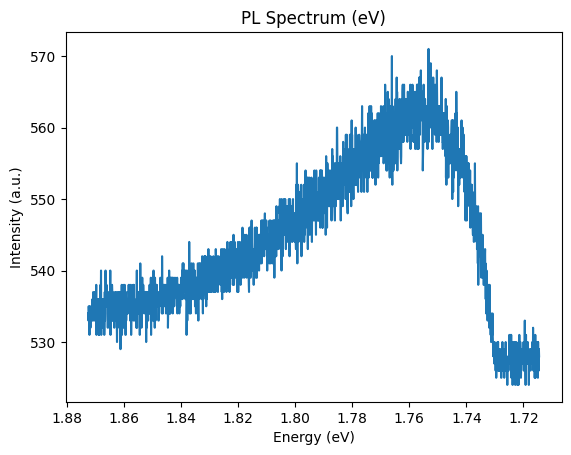

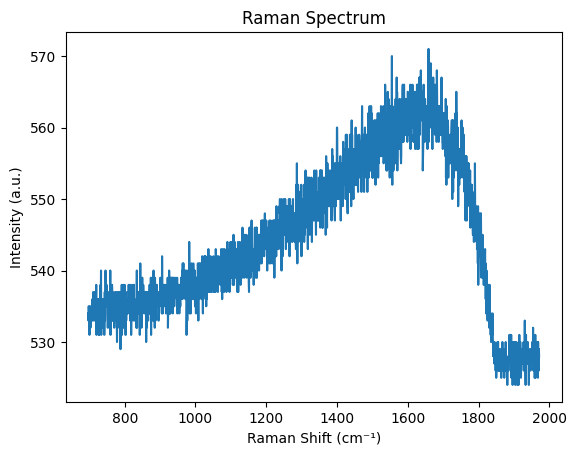

In [53]:
# --- Acquire single frame ---
frame = cam.snap()
spectrum = frame.mean(axis=0) if frame.ndim > 1 else frame

# --- X-axis trimming ---
x_nm = wavelengths[:len(spectrum)]
x_eV = photo_energy[:len(spectrum)]
x_cm = raman_shift[:len(spectrum)]


# --- Plot in nm ---
plt.figure()
plt.plot(x_nm, spectrum, lw=1.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("PL Spectrum (nm)")
plt.show()

# --- Plot in eV ---
plt.figure()
plt.plot(x_eV, spectrum, lw=1.5)
plt.gca().invert_xaxis()
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (a.u.)")
plt.title("PL Spectrum (eV)")
plt.show()

# --- Plot in Raman shift ---
plt.figure()
plt.plot(x_cm, spectrum, lw=1.5)
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("Raman Spectrum")
plt.show()

# Save data
"""
np.savetxt(f"PL_spectrum_nm_Exp{exposure_time}sec.txt", np.column_stack([x_nm, spectrum]),
           header="Wavelength (nm)\tIntensity (a.u.)")
np.savetxt(f"PL_spectrum_eV_Exp{exposure_time}sec.txt", np.column_stack([x_eV, spectrum]),
           header="Energy (eV)\tIntensity (a.u.)")

np.savetxt(f"Raman_spectrum_nm_Exp{exposure_time}sec.txt", np.column_stack([x_cm, spectrum]),
           header="Raman shift (cm-1)\tIntensity (a.u.)")
"""
np.savetxt(f"Spectrum_Exp{exposure_time}sec.txt", np.column_stack([x_nm, x_eV, x_cm, spectrum]),
           header="Wavelength (nm)\tEnergy (eV)\tRaman shift(cm-1)\tIntensity (a.u.)")


# Polarized spectrum

In [ ]:
# Flip mount control
flip_mount.move_to_state(1) # Remove

# --- Measurement loop ---
for angle2 in stage2_steps:
    print(f"\nSetting Stage 2 to {angle2:.1f}°")
    stage2.move_absolute(angle2, blocking=True)
    time.sleep(0.2)  # small settle time

    for angle1 in stage1_steps:
        stage1.move_absolute(angle1, blocking=True)
        time.sleep(0.2)

        # measure power (no arguments needed for get_power())
        frame = cam.snap()
        spectrum = frame.mean(axis=0) if frame.ndim > 1 else frame

        
        # --- X-axis trimming ---
        x_nm = wavelengths[:len(spectrum)]
        x_eV = photo_energy[:len(spectrum)]
        x_cm = raman_shift[:len(spectrum)]
        
        """
        # --- Plot in nm ---
        plt.figure()
        plt.plot(x_nm, spectrum, lw=1.5)
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Intensity (a.u.)")
        plt.title("PL Spectrum (nm)")
        plt.show()
        
        # --- Plot in eV ---
        plt.figure()
        plt.plot(x_eV, spectrum, lw=1.5)
        plt.gca().invert_xaxis()
        plt.xlabel("Energy (eV)")
        plt.ylabel("Intensity (a.u.)")
        plt.title("PL Spectrum (eV)")
        plt.show()
        """
        # --- Plot in Raman shift ---
        plt.figure()
        plt.plot(x_cm, spectrum, lw=1.5)
        plt.xlabel("Raman Shift (cm⁻¹)")
        plt.ylabel("Intensity (a.u.)")
        plt.title(f"Raman Spectrum, Stage1: {angle1}, Stage2: {angle2}")
        plt.show(block=False)
        print(f"  Stage 1: {angle1:.1f}°, Stage 2: {angle2:.1f}° → Power: {power:.4e} W")

        """
        np.savetxt(f"PL_spectrum_nm_Exp{exposure_time}sec.txt", np.column_stack([x_nm, spectrum]),
                   header="Wavelength (nm)\tIntensity (a.u.)")
        np.savetxt(f"PL_spectrum_eV_Exp{exposure_time}sec.txt", np.column_stack([x_eV, spectrum]),
                   header="Energy (eV)\tIntensity (a.u.)")
        """
        filename = f"Raman Spectrum_Exp{exposure_time}sec_Stage1 {angle1}_Stage2 {angle2}.txt"
        np.savetxt(filename, np.column_stack([x_cm, spectrum]),
                   header="Raman shift (cm-1)\tIntensity (a.u.)")
        """
        # Save data
        np.savetxt(f"Spectrum_Exp{exposure_time}sec.txt", np.column_stack([x_nm, x_eV, x_cm, spectrum]),
                   header="Wavelength (nm)\tEnergy (eV)\tRaman shift(cm-1)\tIntensity (a.u.)")
        """

    print(f"Saved: {filename}")
print("\nAll spectra acquired successfully.")

In [56]:
stage1.close()
stage2.close()
spec.close()
cam.close()
pm.close()
flip_mount.close()

In [17]:
stage1.close()